In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import welch, butter, lfilter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import h5py


In [ ]:
class EEGAnesthesiaProcessor:
    """
    A class to handle EEG data loading, preprocessing, and feature extraction 
    specifically for BIS (Depth of Anesthesia) analysis.
    """
    
    def __init__(self, sampling_rate=256):
        self.fs = sampling_rate
        # Frequency bands defined based on clinical standards and the OpenIBIS paper
        self.bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 13),
            'beta': (13, 30),
            'gamma_low': (30, 47)  # Highlighted as critical in the abstract
        }
        

    def load_mat_data(self, file_path):
        """
        Loads MATLAB v7.3 files using h5py. 
        Note: v7.3 files often store data in a transposed format.
        """
        try:
            with h5py.File(file_path, 'r') as f:
                eeg_signal = np.array(f['EEG']).flatten() 
                bis_signal = np.array(f['bis']).flatten()
                
                return eeg_signal, bis_signal
        except Exception as e:
            print(f"Failed to load {file_path} with h5py: {e}")
            raise


    def bandpass_filter(self, data, lowcut=0.5, highcut=50.0, order=4):
        """Applies a Butterworth bandpass filter to remove artifacts and DC offset."""
        nyq = 0.5 * self.fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return lfilter(b, a, data)


    def extract_features(self, eeg_segment):
        """
        Extracts Power Spectral Density (PSD) features using Welch's method.
        This represents the 'Reasoning about data' part of the task.
        """
        freqs, psd = welch(eeg_segment, self.fs, nperseg=self.fs*2)
        
        features = {}
        total_power = np.sum(psd)
        
        for band, (low, high) in self.bands.items():
            # Find indices corresponding to the frequency band
            idx = np.logical_and(freqs >= low, freqs <= high)
            band_power = np.sum(psd[idx])
            # Use relative power to normalize across different patients/cases
            features[f'rel_{band}'] = band_power / total_power if total_power > 0 else 0
            
        return features


    def process_case(self, eeg_raw, bis_raw, window_sec=2):
        """
        Segments the long EEG signal into windows to match BIS time-resolution.
        """
        step = window_sec * self.fs
        num_windows = len(eeg_raw) // step
        
        feature_list = []
        labels = []
        
        # We assume BIS is recorded at a lower frequency (e.g., 1Hz)
        # We need to sync EEG segments with corresponding BIS values
        bis_resampled = np.interp(
            np.linspace(0, len(bis_raw), num_windows), 
            np.arange(len(bis_raw)), 
            bis_raw
        )

        for i in range(num_windows):
            segment = eeg_raw[i*step : (i+1)*step]
            feat = self.extract_features(segment)
            feature_list.append(feat)
            
            # Labeling: Convert continuous BIS (0-100) to categories
            # 0: Deep (0-40), 1: Moderate (40-60), 2: Light/Awake (>60)
            bis_val = bis_resampled[i]
            if bis_val < 40:
                labels.append(0)
            elif bis_val <= 60:
                labels.append(1)
            else:
                labels.append(2)
                
        return pd.DataFrame(feature_list), np.array(labels), bis_resampled



In [10]:
class BISTrainingPipeline:
    """
    Handles model training, evaluation, and visualization.
    """
    def __init__(self):
        self.model = RandomForestClassifier(n_estimators=100, random_state=42)

    def train(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
        self.model.fit(X_train, y_train)
        
        y_pred = self.model.predict(X_test)
        print("--- Model Evaluation ---")
        print(classification_report(y_test, y_pred))
        return self.model

    def plot_comparison(self, true_bis, pred_bis_labels, case_id):
        """Visualizes the ground truth vs predicted anesthesia levels."""
        plt.figure(figsize=(12, 5))
        plt.plot(true_bis, label='Ground Truth BIS', color='blue', alpha=0.6)
        
        # Scaling labels back to BIS range for visualization purposes
        # (e.g., mapping class 1 to a center value of 50)
        visual_pred = np.array([20 if l==0 else 50 if l==1 else 85 for l in pred_bis_labels])
        plt.step(range(len(visual_pred)), visual_pred, label='Predicted Level', color='red', where='post')
        
        plt.title(f"Comparison of BIS Scores - Case {case_id}")
        plt.xlabel("Time (Windows)")
        plt.ylabel("BIS / Anesthesia Level")
        plt.legend()
        plt.grid(True, linestyle='--')
        plt.show()


In [15]:
import os

# Initialize components
processor = EEGAnesthesiaProcessor(sampling_rate=256)
pipeline = BISTrainingPipeline()

# Data storage for training
train_features = []
train_labels = []

# Directory where your .mat files are stored
data_dir = "./data/" # Update this to your actual path


In [13]:
import h5py

file_path = './data/case1.mat'
with h5py.File(file_path, 'r') as f:
    print("--- Top Level Keys ---")
    print(list(f.keys()))
    
    # If there is a group, let's look one level deeper
    for key in f.keys():
        if isinstance(f[key], h5py.Group):
            print(f"--- Keys inside group '{key}' ---")
            print(list(f[key].keys()))

--- Top Level Keys ---
['EEG', 'bis']


In [16]:
# --- Step 1: Training Phase (using Cases 1 to 22) ---
print("Starting data processing for training...")
for i in range(1, 23):
    file_name = f"case{i}.mat"
    file_path = os.path.join(data_dir, file_name)
    
    if os.path.exists(file_path):
        try:
            # Load and preprocess
            eeg, bis = processor.load_mat_data(file_path)
            filtered_eeg = processor.bandpass_filter(eeg)
            
            # Extract features and align with labels
            df_feat, labels, _ = processor.process_case(filtered_eeg, bis)
            
            train_features.append(df_feat)
            train_labels.append(labels)
            print(f"Successfully processed {file_name}")
        except Exception as e:
            print(f"Error processing {file_name}: {e}")

# Combine all training data
X_train_full = pd.concat(train_features, ignore_index=True)
y_train_full = np.concatenate(train_labels)

# Train the model
pipeline.train(X_train_full, y_train_full)

Starting data processing for training...
Successfully processed case1.mat
Successfully processed case2.mat
Successfully processed case3.mat
Successfully processed case4.mat
Successfully processed case5.mat
Successfully processed case6.mat
Successfully processed case7.mat
Successfully processed case8.mat
Successfully processed case9.mat
Successfully processed case10.mat
Successfully processed case11.mat
Successfully processed case12.mat
Successfully processed case13.mat
Successfully processed case14.mat
Successfully processed case15.mat
Successfully processed case16.mat
Successfully processed case17.mat
Successfully processed case18.mat
Successfully processed case19.mat
Successfully processed case20.mat
Successfully processed case21.mat
Successfully processed case22.mat
--- Model Evaluation ---
              precision    recall  f1-score   support

           0       0.69      0.77      0.73      3656
           1       0.61      0.58      0.59      2884
           2       0.59      0.4

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric


--- Running Final Evaluation on Test Cases ---


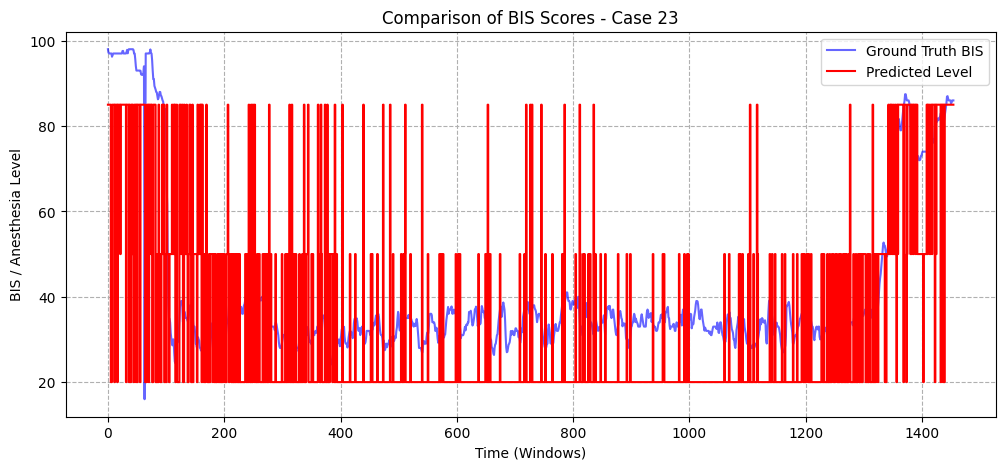

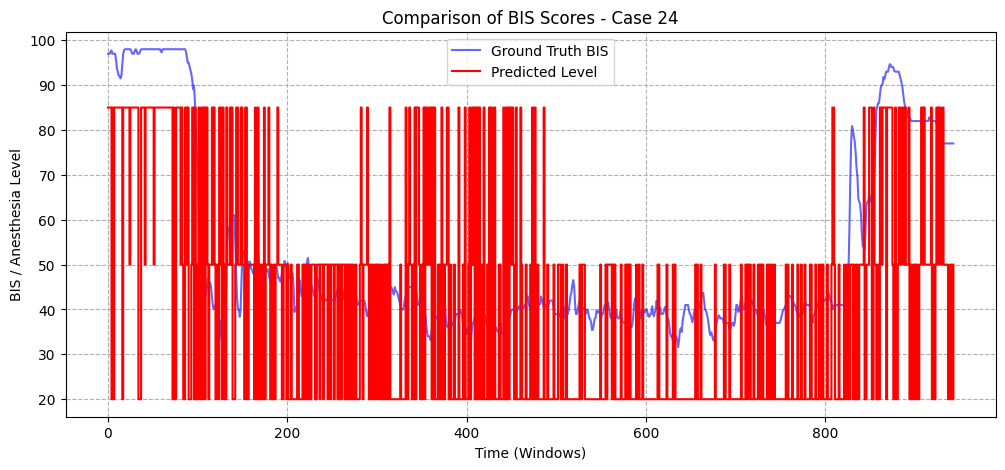

In [ ]:
# Evaluation & Comparison Phase (using Case 23 & 24)
print("\n--- Running Final Evaluation on Test Cases ---")
for test_id in [23, 24]:
    test_file = os.path.join(data_dir, f"case{test_id}.mat")
    if os.path.exists(test_file):
        eeg_test, bis_test = processor.load_mat_data(test_file)
        filtered_eeg_test = processor.bandpass_filter(eeg_test)
        
        # Get features and the continuous ground truth BIS for plotting
        df_feat_test, _, true_bis_curve = processor.process_case(filtered_eeg_test, bis_test)
        
        # Predict using the trained model
        predictions = pipeline.model.predict(df_feat_test)
        
        # Visual comparison as requested in the task
        pipeline.plot_comparison(true_bis_curve, predictions, case_id=test_id)